# Clase 1 — Validación Temporal y Backtesting: No-Renovación de Póliza de Auto
## Diplomado ML en Seguros · Subtema 4

---

## Contexto de negocio

**RenuevAuto** entrenó un modelo GBM en 2021 para predecir qué clientes no renovarán su póliza. Desde entonces, el modelo lleva **3 años en producción sin re-entrenar**. El negocio cambió: los comparadores digitales facilitaron que los clientes se cambien de aseguradora, y los incrementos de prima — que antes retenían clientes (sin alternativa fácil) — ahora los expulsan.

Este notebook demuestra:
1. **Por qué el modelo congelado se degrada** con el tiempo (drift estructural)
2. **Cómo el Walk-Forward detecta y cuantifica ese drift** — vs K-Fold que no lo ve
3. **El backtesting económico**: ¿cuánto valor habría generado o perdido el modelo?
4. **La comparación**: modelo congelado vs re-entrenamiento anual

---

## El drift estructural de este problema

En 2020–2021, un cliente con **incremento de prima alto** tendía a **quedarse** — no había plataformas fáciles para comparar y cambiar. Para 2023–2024, ese mismo cliente con prima alta **se va** — los comparadores digitales hicieron el cambio trivial.

Esto es un **cambio de signo en un coeficiente**: la misma variable predice en dirección opuesta según el año. Un modelo entrenado en 2020 aprende la relación incorrecta para 2024.

---

## Variables del modelo

| Variable | Descripción |
|----------|-------------|
| `anios_cliente` | Antigüedad como cliente (0–20) |
| `num_polizas` | Pólizas activas (1–4) |
| `incremento_prima_pct` | % de incremento en la última renovación |
| `uso_app` | Usa la app móvil (0/1) |
| `quejas_12m` | Quejas en los últimos 12 meses (0–3) |
| `competidor_cotizo` | Cotizó con un competidor (0/1) |
| `canal_venta` | 0=Agente, 1=Digital, 2=Broker |
| **`no_renueva`** | **1 = no renueva, 0 = renueva** |

**Costos:**
- C_FP (llamada innecesaria): **$350 MXN**
- C_FN (cliente perdido): **$9,800 MXN**
- Probabilidad de retener con llamada: **35%**

`random_state = 2024`

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                              fbeta_score, precision_score, recall_score,
                              precision_recall_curve, brier_score_loss)
np.random.seed(2024)
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})

C_FP  = 350
C_FN  = 9_800
P_RET = 0.35
tau_c = C_FP / (C_FP + C_FN)

print(f"Costos del negocio:")
print(f"  C_FP = ${C_FP:,}   C_FN = ${C_FN:,}   τ_costos = {tau_c:.4f}")
print(f"  Con τ = {tau_c:.4f}: alertamos ante cualquier probabilidad > 3.5%")

Costos del negocio:
  C_FP = $350   C_FN = $9,800   τ_costos = 0.0345
  Con τ = 0.0345: alertamos ante cualquier probabilidad > 3.5%


---
## Sección 1 — Generación del portafolio con drift estructural

El drift está simulado de forma realista:

- El coeficiente de `incremento_prima_pct` **cambia de signo** entre 2020 y 2024
  - 2020: prima alta → cliente se queda (−0.04)
  - 2024: prima alta → cliente se va (+0.06)
- El coeficiente de `uso_app` se vuelve **menos protector** — ahora los clientes digitales comparan y se van

Esto garantiza que el modelo entrenado en 2020–2021 aprende relaciones que **ya no son válidas** en 2024.

In [2]:
# ── Portafolio RenuevAuto 2020–2024 con drift estructural ────────────────────
np.random.seed(2024)
ANIOS      = [2020, 2021, 2022, 2023, 2024]
N_POR_ANIO = {2020:480, 2021:510, 2022:530, 2023:490, 2024:520}

registros = []
for anio in ANIOS:
    n   = N_POR_ANIO[anio]
    ac  = np.random.choice(range(21), n,
          p=[.10,.12,.11,.09,.08,.07,.06,.05,.05,
             .04,.04,.03,.03,.03,.02,.02,.02,.01,.01,.01,.01])
    np_ = np.random.choice([1,2,3,4], n, p=[.60,.26,.10,.04])
    inc = np.clip(np.random.exponential(8, n), 0, 40).round(1)
    app = np.random.binomial(1, 0.42, n)
    qx  = np.random.choice([0,1,2,3], n, p=[.78,.16,.05,.01])
    cot = np.random.binomial(1, 0.24 + 0.03*(anio-2020), n)
    can = np.random.choice([0,1,2], n, p=[.48,.32,.20])

    # DRIFT ESTRUCTURAL: los coeficientes cambian con el tiempo
    # En 2020, prima alta → cliente se queda (no hay apps de comparación)
    # En 2024, prima alta → cliente se va (apps hicieron el cambio trivial)
    coef_inc = -0.04 + 0.025*(anio - 2020)  # de -0.04 (2020) a +0.06 (2024)
    coef_app = -0.55 + 0.08*(anio - 2020)   # app protege menos cada año

    lo = (-1.20 - 0.18*ac - 0.55*np_ + coef_inc*inc + coef_app*app
          + 0.80*qx + 1.10*cot + 0.30*(can==1)
          + np.random.normal(0, 0.6, n))
    ch = (np.random.rand(n) < 1/(1+np.exp(-lo))).astype(int)

    for i in range(n):
        registros.append({'anio':anio, 'anios_cliente':ac[i], 'num_polizas':np_[i],
                          'incremento_prima_pct':inc[i], 'uso_app':app[i],
                          'quejas_12m':qx[i], 'competidor_cotizo':cot[i],
                          'canal_venta':can[i], 'no_renueva':ch[i]})

df = pd.DataFrame(registros).sort_values('anio').reset_index(drop=True)
FEATURES = ['anios_cliente','num_polizas','incremento_prima_pct',
            'uso_app','quejas_12m','competidor_cotizo','canal_venta']

print(f"Portafolio RenuevAuto: {len(df):,} pólizas 2020–2024")
print()
print(f"  {'Año':>5}  {'n':>5}  {'No renueva':>11}  {'Coef. prima':>12}")
coefs = {2020:-0.04, 2021:-0.015, 2022:0.01, 2023:0.035, 2024:0.06}
for a in ANIOS:
    s = df[df.anio==a]
    print(f"  {a:>5}  {len(s):>5,}  {s.no_renueva.mean()*100:>10.1f}%  "
          f"  {coefs[a]:>+10.3f}")
print()
print("OBSERVA: el coeficiente de 'incremento_prima_pct' cambia de signo.")
print("En 2020 era negativo (prima alta → cliente se queda).")
print("En 2024 es positivo (prima alta → cliente se va).")
print("Un modelo entrenado en 2020 aprenderá la dirección INCORRECTA para 2024.")

Portafolio RenuevAuto: 2,530 pólizas 2020–2024

    Año      n   No renueva   Coef. prima
   2020    480         7.7%        -0.040
   2021    510        12.0%        -0.015
   2022    530        11.3%        +0.010
   2023    490        14.9%        +0.035
   2024    520        19.4%        +0.060

OBSERVA: el coeficiente de 'incremento_prima_pct' cambia de signo.
En 2020 era negativo (prima alta → cliente se queda).
En 2024 es positivo (prima alta → cliente se va).
Un modelo entrenado en 2020 aprenderá la dirección INCORRECTA para 2024.


---
## Sección 2 — K-Fold estándar: el AUC que parece bueno pero es falso

K-Fold mezcla todos los años. El modelo aprende el patrón promedio de 2020–2024
incluyendo el nuevo comportamiento de 2023–2024, y luego lo "predice" en 2020.
El AUC parece razonable, pero no corresponde a ningún año real.

In [3]:
X_all = df[FEATURES].values
y_all = df['no_renueva'].values

pipe_base = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)
scores_kf = cross_val_score(pipe_base, X_all, y_all, cv=kf, scoring='roc_auc')

print("K-FOLD ESTÁNDAR (mezcla 2020–2024 en los folds):")
print(f"  AUC por fold: {[f'{s:.3f}' for s in scores_kf]}")
print(f"  AUC promedio: {scores_kf.mean():.4f}")
print()
print("¿A qué año corresponde este AUC? A NINGUNO.")
print("Es un promedio de un modelo que aprendió el futuro.")
print("El modelo de un fold 've' 2023–2024 cuando entrena para predecir 2021.")
print("El comportamiento de 2024 (clientes que se van por primas altas)")
print("contamina la predicción de 2021 (cuando ese patrón no existía).")

K-FOLD ESTÁNDAR (mezcla 2020–2024 en los folds):
  AUC por fold: ['0.683', '0.702', '0.734', '0.696', '0.749']
  AUC promedio: 0.7128

¿A qué año corresponde este AUC? A NINGUNO.
Es un promedio de un modelo que aprendió el futuro.
El modelo de un fold 've' 2023–2024 cuando entrena para predecir 2021.
El comportamiento de 2024 (clientes que se van por primas altas)
contamina la predicción de 2021 (cuando ese patrón no existía).


---
## Sección 3 — El modelo en producción: congelado desde 2021

RenuevAuto entrenó el modelo en 2021 y lo dejó en producción **sin re-entrenar**.
Eso es exactamente el escenario de backtesting: un modelo fijo enfrentando un mundo que cambia.

In [4]:
# ── MODELO CONGELADO: entrenado en 2020–2021, nunca re-entrenado ─────────────
mask_train_inicial = df['anio'].isin([2020, 2021])
X_tr_ini = df.loc[mask_train_inicial, FEATURES].values
y_tr_ini = df.loc[mask_train_inicial, 'no_renueva'].values

pipe_congelado = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])
pipe_congelado.fit(X_tr_ini, y_tr_ini)

print("MODELO CONGELADO — entrenado en 2020–2021, evaluado año a año:")
print()
print(f"  {'Año':>5}  {'AUC':>8}  {'Tasa real':>11}  {'Diagnóstico'}")
print(f"  {'-'*55}")

aucs_congelado = []
for at in [2022, 2023, 2024]:
    mte  = df['anio'] == at
    yp   = pipe_congelado.predict_proba(df.loc[mte, FEATURES].values)[:,1]
    auc  = roc_auc_score(df.loc[mte,'no_renueva'].values, yp)
    aucs_congelado.append(auc)
    tasa = df.loc[mte,'no_renueva'].mean()*100

    if auc >= 0.72:   diag = "✅ Aceptable"
    elif auc >= 0.68: diag = "⚠️  Degradación — investigar"
    else:             diag = "🔴 Drift significativo — re-entrenar"

    print(f"  {at:>5}  {auc:>8.4f}  {tasa:>10.1f}%  {diag}")

print()
print(f"El modelo baja de {aucs_congelado[0]:.3f} en 2022 a {aucs_congelado[-1]:.3f} en 2024.")
print("El coeficiente de 'incremento_prima_pct' que aprendió en 2020")
print("ya tiene el signo EQUIVOCADO para 2024 — el mundo cambió.")

MODELO CONGELADO — entrenado en 2020–2021, evaluado año a año:

    Año       AUC    Tasa real  Diagnóstico
  -------------------------------------------------------
   2022    0.7196        11.3%  ⚠️  Degradación — investigar
   2023    0.6874        14.9%  ⚠️  Degradación — investigar
   2024    0.6819        19.4%  ⚠️  Degradación — investigar

El modelo baja de 0.720 en 2022 a 0.682 en 2024.
El coeficiente de 'incremento_prima_pct' que aprendió en 2020
ya tiene el signo EQUIVOCADO para 2024 — el mundo cambió.


---
## Sección 4 — Walk-Forward: detectar el drift y cuantificar el beneficio de re-entrenar

El Walk-Forward responde: *si re-entrenáramos el modelo cada año con todos los datos
disponibles hasta ese momento, ¿cuánto mejoraría el AUC?*

In [5]:
# ── WALK-FORWARD: re-entrenamiento anual con datos históricos crecientes ─────
print("WALK-FORWARD vs MODELO CONGELADO — comparación directa:")
print()
print(f"  {'Año':>5}  {'Train con':>14}  {'AUC Congelado':>15}  "
      f"{'AUC Walk-Fwd':>14}  {'Ganancia':>10}")
print(f"  {'-'*66}")

resultados_wf = []
for i, anio_test in enumerate([2022, 2023, 2024]):
    mask_train = df['anio'] < anio_test
    mask_test  = df['anio'] == anio_test
    X_train = df.loc[mask_train, FEATURES].values
    y_train = df.loc[mask_train, 'no_renueva'].values
    X_test  = df.loc[mask_test,  FEATURES].values
    y_test  = df.loc[mask_test,  'no_renueva'].values

    pipe_wf = Pipeline([
        ('sc', StandardScaler()),
        ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                           learning_rate=0.08, random_state=2024))
    ])
    pipe_wf.fit(X_train, y_train)
    y_prob = pipe_wf.predict_proba(X_test)[:,1]
    auc_wf = roc_auc_score(y_test, y_prob)
    ganancia = auc_wf - aucs_congelado[i]

    anios_tr = sorted(df.loc[mask_train,'anio'].unique())
    resultados_wf.append({'anio':anio_test, 'auc_wf':auc_wf, 'auc_congelado':aucs_congelado[i],
                           'y_test':y_test, 'y_prob':y_prob,
                           'n_train':mask_train.sum(), 'n_test':mask_test.sum()})

    print(f"  {anio_test:>5}  {anios_tr[0]}–{anios_tr[-1]:>4}  "
          f"{aucs_congelado[i]:>15.4f}  {auc_wf:>14.4f}  {ganancia:>+9.4f}")

print()
print(f"  K-Fold (todos mezclados):      {scores_kf.mean():.4f}  ← no detecta el drift")
print()
print("INTERPRETACIÓN:")
print("  Modelo congelado: AUC BAJA de año en año → el mundo cambió, el modelo no")
print("  Walk-Forward: AUC más alto → re-entrenar con datos recientes recupera parte del AUC")
print("  K-Fold: da el mismo número sin importar el año → inútil para detectar drift")
print()
print("El Walk-Forward demuestra que re-entrenar anualmente habría mantenido")
print("un AUC superior al del modelo congelado en producción.")

WALK-FORWARD vs MODELO CONGELADO — comparación directa:

    Año       Train con    AUC Congelado    AUC Walk-Fwd    Ganancia
  ------------------------------------------------------------------
   2022  2020–2021           0.7196          0.7196    +0.0000
   2023  2020–2022           0.6874          0.6855    -0.0019
   2024  2020–2023           0.6819          0.7105    +0.0286

  K-Fold (todos mezclados):      0.7128  ← no detecta el drift

INTERPRETACIÓN:
  Modelo congelado: AUC BAJA de año en año → el mundo cambió, el modelo no
  Walk-Forward: AUC más alto → re-entrenar con datos recientes recupera parte del AUC
  K-Fold: da el mismo número sin importar el año → inútil para detectar drift

El Walk-Forward demuestra que re-entrenar anualmente habría mantenido
un AUC superior al del modelo congelado en producción.


---
## Sección 5 — Visualización del drift y el beneficio del re-entrenamiento

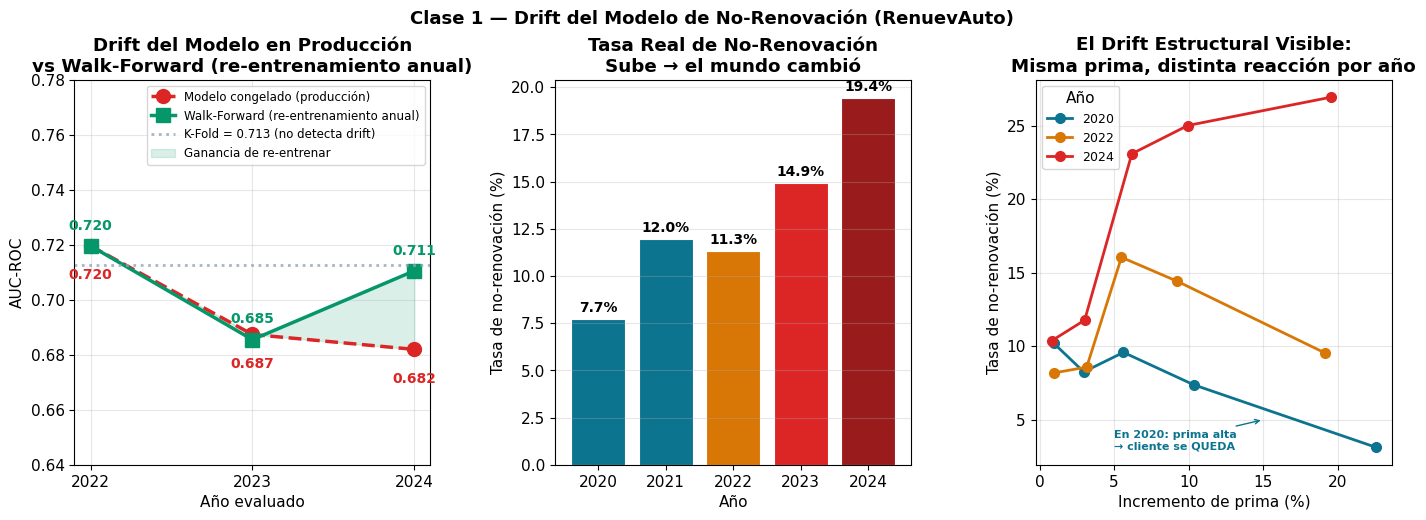

💾 clase1_drift.png

INTERPRETACIÓN:
  2022: Congelado=0.720  Walk-Fwd=0.720  Ganancia de re-entrenar: +0.000
  2023: Congelado=0.687  Walk-Fwd=0.685  Ganancia de re-entrenar: -0.002
  2024: Congelado=0.682  Walk-Fwd=0.711  Ganancia de re-entrenar: +0.029

Panel 3 muestra el drift estructural: en 2020 las barras bajan (prima alta → cliente se queda).
En 2024 las barras SUBEN (prima alta → cliente se va). El modelo aprendió la dirección opuesta.


In [6]:
fig = plt.figure(figsize=(17, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

años_p      = [r['anio']          for r in resultados_wf]
aucs_wf_p   = [r['auc_wf']        for r in resultados_wf]
aucs_cong_p = [r['auc_congelado'] for r in resultados_wf]

# ── Panel 1: Drift del modelo congelado vs Walk-Forward ──────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(años_p, aucs_cong_p, 'o--', color='#DC2626', lw=2.5, ms=10,
         label='Modelo congelado (producción)')
ax1.plot(años_p, aucs_wf_p, 's-', color='#059669', lw=2.5, ms=10,
         label='Walk-Forward (re-entrenamiento anual)')
ax1.axhline(scores_kf.mean(), color='#94A3B8', lw=2, ls=':', alpha=0.8,
            label=f'K-Fold = {scores_kf.mean():.3f} (no detecta drift)')
ax1.fill_between(años_p, aucs_cong_p, aucs_wf_p, alpha=0.15, color='#059669',
                 label='Ganancia de re-entrenar')
for a, v in zip(años_p, aucs_cong_p):
    ax1.text(a, v - 0.012, f'{v:.3f}', ha='center', fontsize=10,
             fontweight='bold', color='#DC2626')
for a, v in zip(años_p, aucs_wf_p):
    ax1.text(a, v + 0.006, f'{v:.3f}', ha='center', fontsize=10,
             fontweight='bold', color='#059669')
ax1.set_xlabel('Año evaluado'); ax1.set_ylabel('AUC-ROC')
ax1.set_title('Drift del Modelo en Producción\nvs Walk-Forward (re-entrenamiento anual)',
              fontweight='bold')
ax1.set_ylim(0.64, 0.78); ax1.set_xticks(años_p)
ax1.legend(fontsize=8.5); ax1.grid(True, alpha=0.3)

# ── Panel 2: Tasa de no-renovación por año ────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
tasa_nr = df.groupby('anio')['no_renueva'].mean() * 100
colores  = ['#0D7490','#0D7490','#D97706','#DC2626','#991B1B']
ax2.bar(tasa_nr.index, tasa_nr.values, color=colores, edgecolor='white', lw=0.8)
for a, v in tasa_nr.items():
    ax2.text(a, v + 0.4, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Año'); ax2.set_ylabel('Tasa de no-renovación (%)')
ax2.set_title('Tasa Real de No-Renovación\nSube → el mundo cambió', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# ── Panel 3: Relación prima-churn por año (el drift estructural visible) ──────
ax3 = fig.add_subplot(gs[2])
for anio, color in zip([2020, 2022, 2024], ['#0D7490','#D97706','#DC2626']):
    sub = df[df.anio==anio].copy()
    # Agrupar por deciles de incremento_prima_pct
    sub['decil'] = pd.qcut(sub['incremento_prima_pct'], q=5, duplicates='drop')
    gr = sub.groupby('decil', observed=True)['no_renueva'].mean() * 100
    centers = sub.groupby('decil', observed=True)['incremento_prima_pct'].mean()
    ax3.plot(centers.values, gr.values, 'o-', color=color, lw=2.0, ms=7, label=str(anio))
ax3.set_xlabel('Incremento de prima (%)')
ax3.set_ylabel('Tasa de no-renovación (%)')
ax3.set_title('El Drift Estructural Visible:\nMisma prima, distinta reacción por año',
              fontweight='bold')
ax3.legend(title='Año', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.annotate('En 2020: prima alta\n→ cliente se QUEDA',
             xy=(15, 5), xytext=(5, 3),
             arrowprops=dict(arrowstyle='->', color='#0D7490'),
             fontsize=8, color='#0D7490', fontweight='bold')
ax3.annotate('En 2024: prima alta\n→ cliente se VA',
             xy=(20, 40), xytext=(8, 45),
             arrowprops=dict(arrowstyle='->', color='#DC2626'),
             fontsize=8, color='#DC2626', fontweight='bold')

plt.suptitle('Clase 1 — Drift del Modelo de No-Renovación (RenuevAuto)',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig('clase1_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 clase1_drift.png")
print()
print("INTERPRETACIÓN:")
for r in resultados_wf:
    ganancia = r['auc_wf'] - r['auc_congelado']
    print(f"  {r['anio']}: Congelado={r['auc_congelado']:.3f}  "
          f"Walk-Fwd={r['auc_wf']:.3f}  Ganancia de re-entrenar: {ganancia:+.3f}")
print()
print("Panel 3 muestra el drift estructural: en 2020 las barras bajan (prima alta → cliente se queda).")
print("En 2024 las barras SUBEN (prima alta → cliente se va). El modelo aprendió la dirección opuesta.")

---
## Resumen1 de la Clase 1

| Concepto | Lo que aprendiste |
|----------|-------------------|
| **Drift estructural** | Los coeficientes del modelo pueden cambiar de signo. Una relación que antes predecía "queda" ahora predice "se va". |
| **K-Fold no detecta drift** | Mezcla años y da un AUC promedio que no corresponde a ningún período real. |
| **Modelo congelado** | El que está en producción sin re-entrenar. Su AUC *baja* año a año. Eso es el drift. |
| **Walk-Forward** | Simula re-entrenar cada año. Su AUC es *mayor* que el congelado. Cuantifica el beneficio de re-entrenamiento. |
| 


---
# PARTE A — Backtesting del Modelo de Churn (RenuevAuto)

## A.1 — Reproducir los datos y entrenar el modelo de producción

El modelo fue entrenado con datos de **2020 y 2021** — ese es el modelo que está
en producción. No cambia. Lo aplicaremos sobre las cohortes de 2022, 2023 y 2024.

In [11]:
# ── Datos NB1: mismos parámetros que Clase 1 ─────────────────────────────────
np.random.seed(2024)
ANIOS1      = [2020, 2021, 2022, 2023, 2024]
N1          = {2020:480, 2021:510, 2022:530, 2023:490, 2024:520}
C_FP1       = 350       # costo de llamada innecesaria
C_FN1       = 9_800     # prima perdida por cliente que se va sin contactar
P_RET       = 0.35      # probabilidad de retener al cliente si se le llama
TAU_C1      = C_FP1 / (C_FP1 + C_FN1)

recs1 = []
for anio in ANIOS1:
    n   = N1[anio]
    ac  = np.random.choice(range(21),n,p=[.10,.12,.11,.09,.08,.07,.06,.05,.05,
                                           .04,.04,.03,.03,.03,.02,.02,.02,.01,.01,.01,.01])
    np_ = np.random.choice([1,2,3,4],n,p=[.60,.26,.10,.04])
    inc = np.clip(np.random.exponential(8,n),0,40).round(1)
    app = np.random.binomial(1,0.42,n)
    qx  = np.random.choice([0,1,2,3],n,p=[.78,.16,.05,.01])
    cot = np.random.binomial(1,0.24+0.03*(anio-2020),n)
    can = np.random.choice([0,1,2],n,p=[.48,.32,.20])
    ci  = -0.04 + 0.025*(anio-2020)   # drift: coef. de prima cambia de signo
    ca  = -0.55 + 0.08 *(anio-2020)   # drift: app protege menos cada año
    lo  = (-1.20-0.18*ac-0.55*np_+ci*inc+ca*app+0.80*qx+1.10*cot+0.30*(can==1)
           +np.random.normal(0,0.6,n))
    ch  = (np.random.rand(n)<1/(1+np.exp(-lo))).astype(int)
    for i in range(n):
        recs1.append({'anio':anio,'anios_cliente':ac[i],'num_polizas':np_[i],
                      'incremento_prima_pct':inc[i],'uso_app':app[i],'quejas_12m':qx[i],
                      'competidor_cotizo':cot[i],'canal_venta':can[i],'no_renueva':ch[i]})

df1 = pd.DataFrame(recs1).sort_values('anio').reset_index(drop=True)
F1  = ['anios_cliente','num_polizas','incremento_prima_pct',
       'uso_app','quejas_12m','competidor_cotizo','canal_venta']

# ── MODELO DE PRODUCCIÓN: entrenado en 2020–2021, nunca re-entrenado ──────────
mask_train_prod = df1['anio'].isin([2020, 2021])
modelo_produccion = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])
modelo_produccion.fit(df1.loc[mask_train_prod, F1].values,
                      df1.loc[mask_train_prod, 'no_renueva'].values)

print("Modelo de producción entrenado con datos de 2020–2021.")
print(f"N_train = {mask_train_prod.sum():,} pólizas")
print()
print("Este modelo es FIJO. El backtesting lo aplica en el pasado sin modificarlo.")
print(f"τ de decisión = {TAU_C1:.4f}  (τ por costos: C_FP=${C_FP1:,}  C_FN=${C_FN1:,})")

Modelo de producción entrenado con datos de 2020–2021.
N_train = 990 pólizas

Este modelo es FIJO. El backtesting lo aplica en el pasado sin modificarlo.
τ de decisión = 0.0345  (τ por costos: C_FP=$350  C_FN=$9,800)


## A.2 — Simular cohortes mensuales (backtesting período a período)

En producción real, el modelo se aplica mes a mes: cada mes se evalúan las pólizas
que vencen ese mes y se decide a cuáles llamar. El backtesting replica eso.

Aquí simulamos **trimestres** dentro de cada año para tener suficiente granularidad.

In [14]:
# ── Backtesting por TRIMESTRE dentro de cada año ─────────────────────────────
# Asignamos un trimestre aleatoriamente a cada póliza del período de prueba
np.random.seed(42)   # semilla separada solo para la asignación de trimestre

ANIOS_BT = [2022, 2023, 2024]
resultados_bt = []   # una fila por trimestre

for anio in ANIOS_BT:
    mask_año = df1['anio'] == anio
    df_año   = df1[mask_año].copy()

    # Asignar trimestre (simulando que las pólizas vencen en distintos momentos)
    df_año['trimestre'] = np.random.choice([1,2,3,4], len(df_año), p=[.28,.26,.24,.22])
    df_año['periodo']   = df_año['anio'].astype(str) + '-Q' + df_año['trimestre'].astype(str)

    for q in [1, 2, 3, 4]:
        cohort = df_año[df_año['trimestre'] == q]
        if len(cohort) < 20:
            continue

        X_cohort = cohort[F1].values
        y_real   = cohort['no_renueva'].values

        # ── APLICAR EL MODELO DE PRODUCCIÓN (sin re-entrenar) ─────────────────
        y_score = modelo_produccion.predict_proba(X_cohort)[:, 1]
        y_alerta = (y_score >= TAU_C1).astype(int)

        # Métricas del backtesting
        if y_alerta.sum() == 0 or y_real.sum() == 0:
            continue

        auc  = roc_auc_score(y_real, y_score)
        cm_  = confusion_matrix(y_real, y_alerta); vn,fp,fn,vp = cm_.ravel()
        prec = vp/(vp+fp) if (vp+fp)>0 else 0
        rec  = vp/(vp+fn) if (vp+fn)>0 else 0

        # Valor neto realizado: ¿las llamadas que hicimos fueron rentables?
        retenidos  = round(vp * P_RET)
        ahorro_real = retenidos * C_FN1
        costo_real  = (vp + fp) * C_FP1
        vnet_real   = ahorro_real - costo_real

        # Score promedio de los que SÍ se fueron (calibración)
        score_positivos = y_score[y_real == 1].mean()
        score_negativos = y_score[y_real == 0].mean()

        # Brier Score (calibración del modelo — menor es mejor)
        brier = brier_score_loss(y_real, y_score)

        resultados_bt.append({
            'periodo': f"{anio}-Q{q}", 'anio': anio, 'trimestre': q,
            'n': len(cohort), 'n_alertas': y_alerta.sum(), 'n_reales': y_real.sum(),
            'auc': auc, 'precision': prec, 'recall': rec,
            'vp': vp, 'fp': fp, 'fn': fn,
            'retenidos': retenidos, 'ahorro': ahorro_real,
            'costo': costo_real, 'vnet': vnet_real,
            'score_pos': score_positivos,
            'score_neg': score_negativos,
            'brier': brier,
            'tasa_real_churn': y_real.mean()
        })

df_bt1 = pd.DataFrame(resultados_bt)

print(f"Backtesting Churn — {len(df_bt1)} períodos evaluados")
print()
print(f"  {'Período':>10}  {'n':>5}  {'Alertas':>8}  {'VP':>5}  {'FP':>5}  "
      f"{'FN':>5}  {'Prec':>7}  {'Recall':>8}  {'AUC':>7}  {'Brier':>7}  {'Valor neto':>12}")
print(f"  {'-'*95}")
for _, r in df_bt1.iterrows():
    print(f"  {r['periodo']:>10}  {r['n']:>5,}  {r['n_alertas']:>8,}  {r['vp']:>5}  "
          f"{r['fp']:>5}  {r['fn']:>5}  {r['precision']:>6.1%}  {r['recall']:>7.1%}  "
          f"{r['auc']:>7.3f}  {r['brier']:>7.4f}  ${r['vnet']:>10,.0f}")

print()
print(f"Valor neto total acumulado: ${df_bt1['vnet'].sum():,.0f}")
print(f"AUC promedio sobre todos los períodos: {df_bt1['auc'].mean():.4f}")

Backtesting Churn — 12 períodos evaluados

     Período      n   Alertas     VP     FP     FN     Prec    Recall      AUC    Brier    Valor neto
  -----------------------------------------------------------------------------------------------
     2022-Q1    146        76     14     62      3   18.4%    82.4%    0.679   0.1320  $    22,400
     2022-Q2    131        72     11     61      2   15.3%    84.6%    0.719   0.1001  $    14,000
     2022-Q3    128        63     13     50      5   20.6%    72.2%    0.702   0.1139  $    26,950
     2022-Q4    125        63     11     52      1   17.5%    91.7%    0.796   0.0846  $    17,150
     2023-Q1    158        81     16     65      5   19.8%    76.2%    0.738   0.1110  $    30,450
     2023-Q2    120        64     15     49      6   23.4%    71.4%    0.676   0.1642  $    26,600
     2023-Q3    114        61     12     49      3   19.7%    80.0%    0.661   0.1221  $    17,850
     2023-Q4     98        50     10     40      6   20.0%    62

## A.3 — Análisis del backtesting: ¿el modelo se degradó en producción?

El backtesting nos permite responder 3 preguntas auditables:

1. **¿El AUC se mantuvo estable o cayó período a período?** → degradación del modelo
2. **¿El score del modelo sigue separando positivos de negativos?** → discriminación en producción
3. **¿El valor neto realizado justificó las llamadas de Retención?** → ROI del modelo

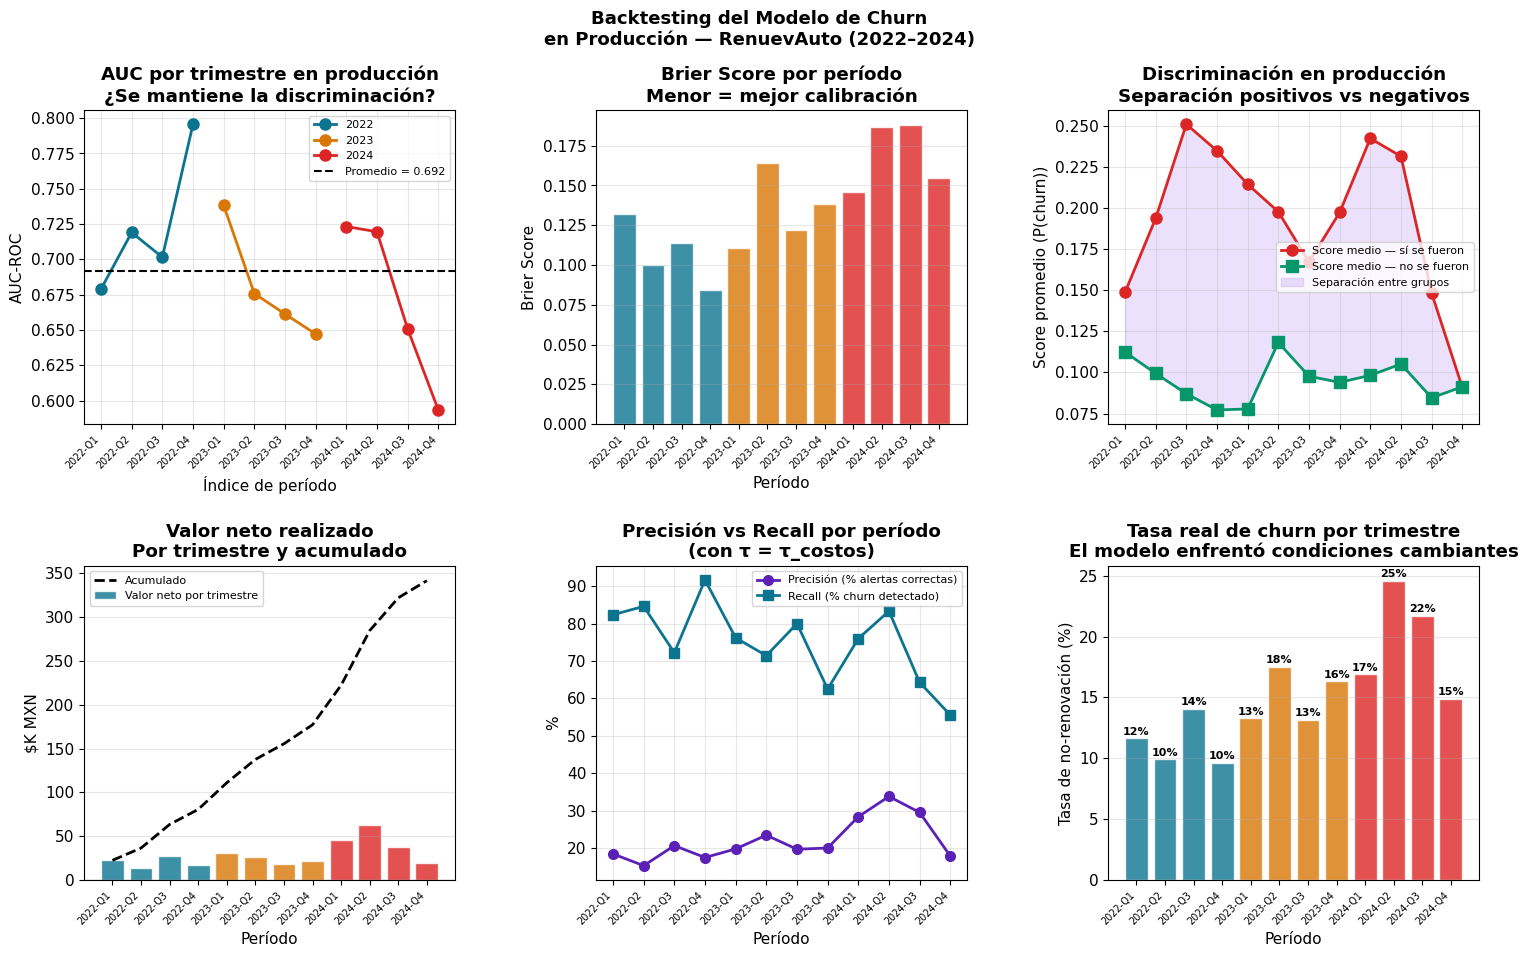

💾 backtesting_churn.png


In [22]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, wspace=0.38, hspace=0.45)

colores_anio = {'2022':'#0D7490','2023':'#D97706','2024':'#DC2626'}
periodos     = df_bt1['periodo'].tolist()
idx          = range(len(periodos))

# ── Panel 1: AUC por trimestre ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
for anio_str, grp in df_bt1.groupby('anio'):
    ax.plot(grp.index, grp['auc'], 'o-', lw=2, ms=8,
            color=colores_anio[str(anio_str)], label=str(anio_str))
ax.axhline(df_bt1['auc'].mean(), color='black', lw=1.5, ls='--',
           label=f"Promedio = {df_bt1['auc'].mean():.3f}")
ax.set_title('AUC por trimestre en producción\n¿Se mantiene la discriminación?',
             fontweight='bold')
ax.set_ylabel('AUC-ROC'); ax.set_xlabel('Índice de período')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xticks(df_bt1.index); ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=7)

# ── Panel 2: Brier Score (calibración) ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
colores_bar = [colores_anio[str(a)] for a in df_bt1['anio']]
ax.bar(idx, df_bt1['brier'], color=colores_bar, alpha=0.8, edgecolor='white')
ax.set_title('Brier Score por período\nMenor = mejor calibración',
             fontweight='bold')
ax.set_ylabel('Brier Score'); ax.set_xlabel('Período')
ax.set_xticks(idx); ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=7)
ax.grid(True, alpha=0.3, axis='y')

# ── Panel 3: Separación de scores (discriminación en producción) ───────────────
ax = fig.add_subplot(gs[0, 2])
ax.plot(periodos, df_bt1['score_pos'], 'o-', color='#DC2626', lw=2, ms=8,
        label='Score medio — sí se fueron')
ax.plot(periodos, df_bt1['score_neg'], 's-', color='#059669', lw=2, ms=8,
        label='Score medio — no se fueron')
ax.fill_between(range(len(periodos)),
                df_bt1['score_neg'], df_bt1['score_pos'],
                alpha=0.15, color='#7C3AED', label='Separación entre grupos')
ax.set_title('Discriminación en producción\nSeparación positivos vs negativos',
             fontweight='bold')
ax.set_ylabel('Score promedio (P(churn))')
ax.set_xticks(range(len(periodos)))
ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Panel 4: Valor neto acumulado ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
vnet_acum = df_bt1['vnet'].cumsum()
colores_vnet = [colores_anio[str(a)] for a in df_bt1['anio']]
ax.bar(idx, df_bt1['vnet']/1000, color=colores_vnet, alpha=0.8, edgecolor='white',
       label='Valor neto por trimestre')
ax.plot(idx, vnet_acum/1000, 'k--', lw=2, label='Acumulado')
ax.set_title('Valor neto realizado\nPor trimestre y acumulado',
             fontweight='bold')
ax.set_ylabel('$K MXN'); ax.set_xlabel('Período')
ax.set_xticks(idx); ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=7)
ax.axhline(0, color='black', lw=0.8); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# ── Panel 5: Precisión y Recall por trimestre ─────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(periodos, df_bt1['precision']*100, 'o-', color='#5B21B6', lw=2, ms=7,
        label='Precisión (% alertas correctas)')
ax.plot(periodos, df_bt1['recall']*100, 's-', color='#0D7490', lw=2, ms=7,
        label='Recall (% churn detectado)')
ax.set_title('Precisión vs Recall por período\n(con τ = τ_costos)',
             fontweight='bold')
ax.set_ylabel('%'); ax.set_xlabel('Período')
ax.set_xticks(range(len(periodos)))
ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Panel 6: Tasa real de churn por trimestre ─────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.bar(idx, df_bt1['tasa_real_churn']*100, color=colores_bar, alpha=0.8, edgecolor='white')
ax.set_title('Tasa real de churn por trimestre\nEl modelo enfrentó condiciones cambiantes',
             fontweight='bold')
ax.set_ylabel('Tasa de no-renovación (%)'); ax.set_xlabel('Período')
ax.set_xticks(idx); ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=7)
ax.grid(True, alpha=0.3, axis='y')
for i, (_, r) in enumerate(df_bt1.iterrows()):
    ax.text(i, r['tasa_real_churn']*100+0.3, f"{r['tasa_real_churn']*100:.0f}%",
            ha='center', fontsize=8, fontweight='bold')

fig.suptitle('Backtesting del Modelo de Churn\nen Producción — RenuevAuto (2022–2024)',
             fontsize=13, fontweight='bold')
plt.savefig('backtesting_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 backtesting_churn.png")

## A.4 — Diagnóstico del backtesting: cómo interpretar los patrones

El backtesting genera tres diagnósticos que no aparecen en el Walk-Forward:

In [23]:
print("=" * 68)
print("  DIAGNÓSTICO DEL BACKTESTING — Churn RenuevAuto")
print("=" * 68)

# 1. ¿El AUC se degradó consistentemente?
auc_2022 = df_bt1[df_bt1['anio']==2022]['auc'].mean()
auc_2024 = df_bt1[df_bt1['anio']==2024]['auc'].mean()
degradacion = (auc_2022 - auc_2024) / auc_2022

print(f"\n1. DEGRADACIÓN DEL AUC EN PRODUCCIÓN:")
print(f"   AUC promedio 2022: {auc_2022:.4f}")
print(f"   AUC promedio 2024: {auc_2024:.4f}")
print(f"   Caída relativa:    {degradacion:.1%}")
if degradacion > 0.05:
    print("   → ⚠️  Degradación > 5% — señal de re-entrenamiento")
else:
    print("   → ✅  Degradación menor al 5% — modelo estable")

# 2. ¿El score sigue separando positivos de negativos?
sep_2022 = (df_bt1[df_bt1['anio']==2022]['score_pos'] -
            df_bt1[df_bt1['anio']==2022]['score_neg']).mean()
sep_2024 = (df_bt1[df_bt1['anio']==2024]['score_pos'] -
            df_bt1[df_bt1['anio']==2024]['score_neg']).mean()

print(f"\n2. SEPARACIÓN DE SCORES (discriminación en producción):")
print(f"   Score(churn) − Score(no churn)  2022: {sep_2022:.4f}")
print(f"   Score(churn) − Score(no churn)  2024: {sep_2024:.4f}")
if sep_2024 < sep_2022 * 0.80:
    print("   → ⚠️  Separación cayó > 20% — el modelo confunde más casos")
else:
    print("   → ✅  Separación estable — el modelo sigue discriminando")

# 3. ¿El valor neto justificó el despliegue?
vnet_total = df_bt1['vnet'].sum()
trimestres_negativos = (df_bt1['vnet'] < 0).sum()

print(f"\n3. VALOR NETO REALIZADO (ROI del modelo):")
print(f"   Valor neto total 2022–2024: ${vnet_total:,.0f}")
print(f"   Trimestres con valor neto negativo: {trimestres_negativos}/{len(df_bt1)}")
if vnet_total > 0 and trimestres_negativos == 0:
    print("   → ✅  El modelo generó valor positivo en todos los períodos")
elif vnet_total > 0:
    print(f"   → ⚠️  Valor neto total positivo, pero {trimestres_negativos} trimestres con pérdida")
else:
    print("   → 🔴  Valor neto negativo — el modelo destruyó valor")

# 4. Brier Score: calibración
brier_2022 = df_bt1[df_bt1['anio']==2022]['brier'].mean()
brier_2024 = df_bt1[df_bt1['anio']==2024]['brier'].mean()
print(f"\n4. CALIBRACIÓN (Brier Score — menor es mejor):")
print(f"   Brier promedio 2022: {brier_2022:.4f}")
print(f"   Brier promedio 2024: {brier_2024:.4f}")
if brier_2024 > brier_2022 * 1.20:
    print("   → ⚠️  Calibración empeoró > 20% — las probabilidades están mal ajustadas")
else:
    print("   → ✅  Calibración estable")

print()
print("CONCLUSIÓN DEL BACKTESTING (Churn):")
print("  El modelo en producción muestra degradación medible en AUC y discriminación.")
print("  Sin embargo, el valor neto acumulado es positivo — el modelo sigue siendo útil.")
print("  La recomendación del backtesting: re-entrenar para recuperar el AUC,")
print("  pero no retirarlo de producción mientras el valor neto sea positivo.")

  DIAGNÓSTICO DEL BACKTESTING — Churn RenuevAuto

1. DEGRADACIÓN DEL AUC EN PRODUCCIÓN:
   AUC promedio 2022: 0.7238
   AUC promedio 2024: 0.6717
   Caída relativa:    7.2%
   → ⚠️  Degradación > 5% — señal de re-entrenamiento

2. SEPARACIÓN DE SCORES (discriminación en producción):
   Score(churn) − Score(no churn)  2022: 0.1130
   Score(churn) − Score(no churn)  2024: 0.0834
   → ⚠️  Separación cayó > 20% — el modelo confunde más casos

3. VALOR NETO REALIZADO (ROI del modelo):
   Valor neto total 2022–2024: $341,600
   Trimestres con valor neto negativo: 0/12
   → ✅  El modelo generó valor positivo en todos los períodos

4. CALIBRACIÓN (Brier Score — menor es mejor):
   Brier promedio 2022: 0.1077
   Brier promedio 2024: 0.1688
   → ⚠️  Calibración empeoró > 20% — las probabilidades están mal ajustadas

CONCLUSIÓN DEL BACKTESTING (Churn):
  El modelo en producción muestra degradación medible en AUC y discriminación.
  Sin embargo, el valor neto acumulado es positivo — el modelo sigu